# 02 · Phases 2–3 — Metadata table and patient-independent split

* Parse every subject `.txt`, `.hea`, `.wav` header and `.tsv` into **`circor_records.csv`**.
* **Recording-level murmur label** (a correction to the draft plan): CirCor's `Murmur` field is
  *patient*-level. A murmur-positive patient's recording is labelled *Present* only if its
  location appears in `Murmur locations`; otherwise the murmur was not audible there and the
  recording is *Absent*. Training a "murmur present" label on inaudible locations would inject
  label noise.
* **Split patients, not recordings**: 70 / 15 / 15, stratified on patient murmur status
  (Present / Absent / Unknown), *before* any windowing. An assertion guarantees no patient
  appears in two splits.

In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb
import matplotlib.pyplot as plt
import seaborn as sns

Python environment is working
PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib


In [2]:
df = build_records_table(P["raw"])
print(f"{len(df)} recordings, {df.patient_id.nunique()} patients, missing files: {(~df.exists).sum()}")
assert df.exists.all()
assert (df.fs_hea == CFG["preprocessing"]["fs_in"]).all() and (df.fs_wav == df.fs_hea).all()
df.head()

3163 recordings, 942 patients, missing files: 0


,record_id,patient_id,location,wav_path,hea_path,tsv_path,exists,patient_murmur,outcome,murmur_locations,most_audible,age,sex,pregnant,height,weight,campaign,sys_timing,dia_timing,sys_shape,dia_shape,sys_grading,dia_grading,sys_pitch,dia_pitch,sys_quality,dia_quality,murmur_label,fs_hea,n_samples,fs_wav,duration_s,annotated_s,n_cycles,heart_rate_tsv,y_murmur,y_outcome
0,13918_AV,13918,AV,training_data\13918_AV.wav,training_data\13918_AV.hea,training_data\13918_AV.tsv,True,Present,Abnormal,TV,TV,Child,Male,False,98.0,15.9,CC2015,Holosystolic,nan,Plateau,nan,I/VI,nan,Low,nan,Blowing,nan,Absent,4000,41152,4000,10.288,8.393798,15,107.222023,0.0,1
1,13918_PV,13918,PV,training_data\13918_PV.wav,training_data\13918_PV.hea,training_data\13918_PV.tsv,True,Present,Abnormal,TV,TV,Child,Male,False,98.0,15.9,CC2015,Holosystolic,nan,Plateau,nan,I/VI,nan,Low,nan,Blowing,nan,Absent,4000,37568,4000,9.392,4.889365,9,110.443790,0.0,1
2,13918_TV,13918,TV,training_data\13918_TV.wav,training_data\13918_TV.hea,training_data\13918_TV.tsv,True,Present,Abnormal,TV,TV,Child,Male,False,98.0,15.9,CC2015,Holosystolic,nan,Plateau,nan,I/VI,nan,Low,nan,Blowing,nan,Present,4000,26368,4000,6.592,5.471676,10,109.655616,1.0,1
3,13918_MV,13918,MV,training_data\13918_MV.wav,training_data\13918_MV.hea,training_data\13918_MV.tsv,True,Present,Abnormal,TV,TV,Child,Male,False,98.0,15.9,CC2015,Holosystolic,nan,Plateau,nan,I/VI,nan,Low,nan,Blowing,nan,Absent,4000,115136,4000,28.784,5.855216,11,112.720009,0.0,1
4,14241_AV,14241,AV,training_data\14241_AV.wav,training_data\14241_AV.hea,training_data\14241_AV.tsv,True,Present,Abnormal,AV+MV+PV+TV,PV,Child,Male,False,87.0,11.2,CC2015,Early-systolic,nan,Plateau,nan,II/VI,nan,Low,nan,Harsh,nan,Present,4000,81920,4000,20.480,6.733033,13,115.846751,1.0,1


> **Note on dataset size.** The PhysioNet page describes 5,272 recordings from 1,568 patients
> for the *whole* CirCor collection, but only the public **training** portion (shown above) is
> downloadable; the rest was the hidden Challenge 2022 validation/test data. All experiments
> therefore use the public v1.0.3 portion, split patient-wise into train/val/test here.

In [3]:
df = patient_split(df, CFG["data"]["split"], CFG["seed"])
df.to_csv(P["metadata"] / "circor_records.csv", index=False)

pat = df.groupby("patient_id").first()
summary = {
    "recordings": len(df),
    "patients": int(df.patient_id.nunique()),
    "patient_murmur": pat.patient_murmur.value_counts().to_dict(),
    "patient_outcome": pat.outcome.value_counts().to_dict(),
    "recording_murmur": df.murmur_label.value_counts().to_dict(),
    "locations": df.location.value_counts().to_dict(),
    "duration_s": df.duration_s.describe().round(2).to_dict(),
}
save_json(summary, P["results"] / "dataset_summary.json")
tab = (df.groupby("split")
         .agg(patients=("patient_id", "nunique"), recordings=("record_id", "size"),
              rec_present=("murmur_label", lambda s: (s == "Present").sum()),
              rec_absent=("murmur_label", lambda s: (s == "Absent").sum()),
              rec_unknown=("murmur_label", lambda s: (s == "Unknown").sum()))
         .loc[["train", "val", "test"]])
tab["pat_present"] = [df[df.split == s].groupby("patient_id").patient_murmur.first().eq("Present").sum() for s in tab.index]
tab.to_csv(P["tables"] / "split_summary.csv")
print(json.dumps(summary, indent=1))
tab

{
 "recordings": 3163,
 "patients": 942,
 "patient_murmur": {
  "Absent": 695,
  "Present": 179,
  "Unknown": 68
 },
 "patient_outcome": {
  "Normal": 486,
  "Abnormal": 456
 },
 "recording_murmur": {
  "Absent": 2508,
  "Present": 499,
  "Unknown": 156
 },
 "locations": {
  "MV": 861,
  "AV": 800,
  "PV": 766,
  "TV": 732,
  "Phc": 4
 },
 "duration_s": {
  "count": 3163.0,
  "mean": 22.87,
  "std": 7.28,
  "min": 5.15,
  "25%": 19.06,
  "50%": 21.46,
  "75%": 29.39,
  "max": 64.51
 }
}


,patients,recordings,rec_present,rec_absent,rec_unknown,pat_present
split,,,,,,
train,658,2210,350,1750,110,125
val,142,474,74,376,24,27
test,142,479,75,382,22,27


In [4]:
leak = df.groupby("patient_id").split.nunique().max()
print("max #splits per patient =", leak, "-> no leakage" if leak == 1 else "LEAK!")
pp = df[df.patient_murmur == "Present"]
print(f"Murmur-positive patients: {pp.patient_id.nunique()}; their recordings: {len(pp)}; "
      f"of which at a murmur location: {(pp.murmur_label == 'Present').sum()} "
      f"({(pp.murmur_label == 'Present').mean():.0%})")

max #splits per patient = 1 -> no leakage
Murmur-positive patients: 179; their recordings: 616; of which at a murmur location: 499 (81%)


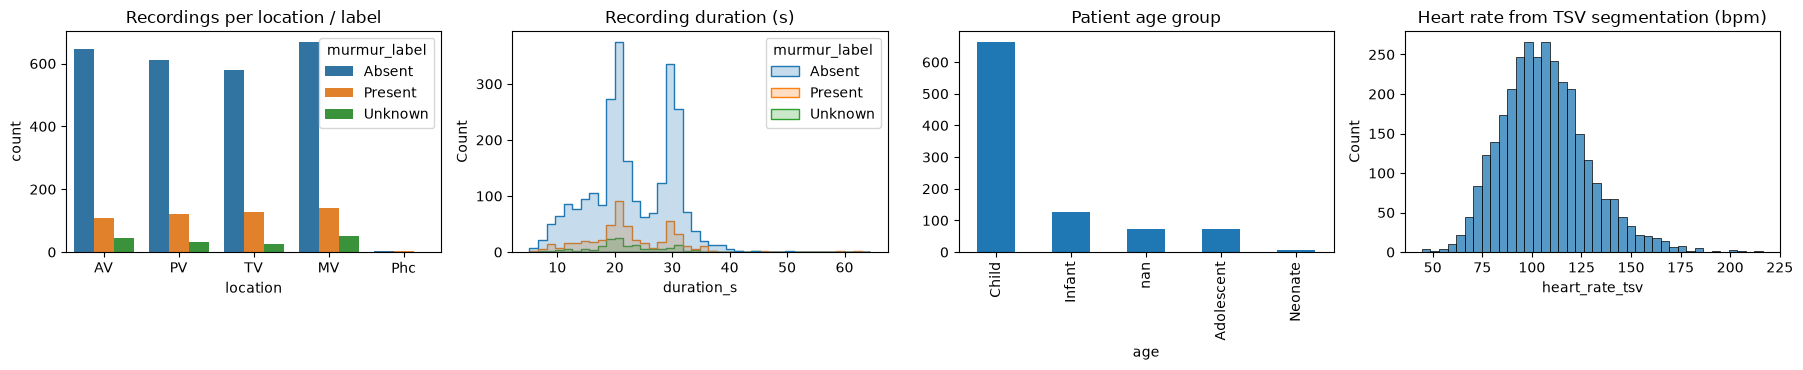

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
sns.countplot(data=df, x="location", hue="murmur_label", ax=ax[0], order=["AV", "PV", "TV", "MV", "Phc"])
ax[0].set_title("Recordings per location / label")
sns.histplot(data=df, x="duration_s", hue="murmur_label", bins=40, ax=ax[1], element="step")
ax[1].set_title("Recording duration (s)")
pat.age.value_counts().plot.bar(ax=ax[2], title="Patient age group")
sns.histplot(df.heart_rate_tsv.dropna(), bins=40, ax=ax[3])
ax[3].set_title("Heart rate from TSV segmentation (bpm)")
plt.tight_layout(); savefig(fig, "02_dataset_overview"); plt.show()

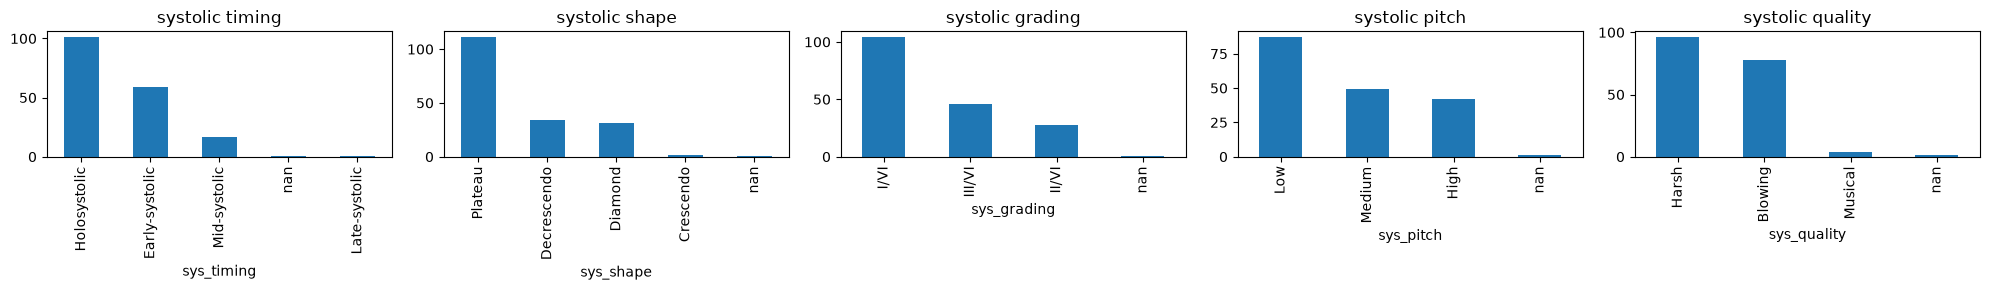

In [6]:
desc = pp.drop_duplicates("patient_id")[["sys_timing", "sys_shape", "sys_grading", "sys_pitch", "sys_quality"]]
fig, ax = plt.subplots(1, 5, figsize=(20, 3))
for a, c in zip(ax, desc.columns):
    desc[c].value_counts().plot.bar(ax=a, title=c.replace("sys_", "systolic "))
plt.tight_layout(); savefig(fig, "02_murmur_descriptors"); plt.show()